# Notas

Error Absoluto ($E_a$): Es la diferencia directa entre el valor exacto ($V_e$) y el aproximado ($V_a$).La fórmula es $E_a = |V_e - V_a|$.

Error Relativo ($E_r$): Relaciona el error con el tamaño del valor real, lo que nos da una mejor perspectiva proporcional. La fórmula es $E_r = \frac{|V_e - V_a|}{|V_e|}$.


Error Porcentual ($E_p$): Es simplemente el error relativo expresado como porcentaje ($E_r \times 100$).


# Funciones Generales

In [ ]:
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial


def Biseccion(f, a, b, tol):
  if (f(a) * f(b) > 0):
    print("bye bye, no hay nada en el intervalo")
  else:
    contador = 0

    while (abs(b - a) > tol):
      p = (a + b) / 2
      contador += 1

      if contador > 100:
        break

      if f(a) * f(p) < 0:
        b = p
      else:
        a = p

    print(f'La solucion de al funcion: {p}')
    print(f'La cantidad de iteraciones necesarias fueron {contador}')

  return p


def PosicionFalsa(f, a, b, tol):
  if (f(a) * f(b) > 0):
    print("bye bye, no hay nada en el intervalo")
  else:
    contador = 0
    p = b - f(b) * (a-b) / (f(a) - f(b))
    while (abs(f(p)) > tol):
      p = b - f(b) * (a-b) / (f(a) - f(b))
      contador += 1

      if contador > 1000:
        break

      if f(a) * f(p) < 0:
        b = p
      else:
        a = p

    print(f'La solucion de al funcion: {p}')
    print(f'La cantidad de iteraciones necesarias fueron {contador}')

  return p


def evaluacion(values, f, p):
  lista = []
  for i in values:
    lista.append([i,f(i), p(i), abs(f(i) - p(i)), abs((f(i)-p(i))/f(i))])

  lista = pd.DataFrame(lista, columns=["values_x", "f(x)", "p(x)", "|f(x)-p(x)| ", "E_r"])

  return lista


def Taylor (f, x0, n):
  polinomio = 0

  for k in range(n+1):
    df = sp.diff(f, x, k)
    df_val = sp.lambdify(x, df)
    polinomio += (df_val(x0)/factorial(k))*(x-x0)**k
  return polinomio


def Newton(f, x0, tol):
  x = sp.symbols('x')
  df = sp.diff(f, x)
  newton = x-f/df
  contador = 0
  error = float('inf')
  while error > tol and contador < 20:
    x1 = newton.subs(x, x0)
    error = abs(x1-x0)
    x0 = x1
    contador += 1
  return float(x1), contador


def Secante(f, x0, x1, tol):
    error = 1
    contador = 0
    while error > tol:
      x2 = x1 - (f(x1) * (x1-x0)) / (f(x1) - f(x0))
      error = abs(x2-x1)
      x0 = x1
      x1 = x2
      contador += 1
    return x2, contador

def eliminacion_gaussiana(A, b):
  n = len(b)
  M = A.astype(float).copy()
  v = b.astype(float).copy()

  for i in range(n):
    for j in range(i + 1, n-1):
        factor = M[j][i] / M[i][i]
        M[j] = M[j] - factor * M[i]
        v[j] = v[j] - factor * v[i]

  return M



def eliminacion_DD_pivoteo(A, b):
    n = len(b)
    M = np.hstack((A, b.reshape(-1, 1))).astype(float)

    print("--- Matriz Original ---")
    print(np.round(M, 2))
    print("\nAplicando Eliminación Gaussiana...\n")

    for i in range(n):

        max_row = np.argmax(abs(M[i:n, i])) + i
        if i != max_row:
            M[[i, max_row]] = M[[max_row, i]]

        for j in range(i + 1, n):
            if M[i, i] == 0:
                continue

            factor = M[j, i] / M[i, i]
            M[j] = M[j] - factor * M[i]

    for i in range(n):
        for j in range(i):
            M[i, j] = 0.0

    print("--- Matriz Triangulada Resultante ---")
    print(np.round(M, 4))

    return M


A = np.array([
    [0,  2,  1],
    [ 6, -8, -2],
    [ 1, -1, -2]
])
b = np.array([2, 1, 3])

M_triangulada = eliminacion_DD_pivoteo(A, b)

# CLASE 1


##Ejercicio 1

Calcular area y perimetro de un circulo y volumen de esfera

El perimetro de un circulo es $P = 2\pi r $

El Area es $ A = \pi r^2$

El volumen de un esfera es $V = \frac{4}{3}\pi r^3$

In [ ]:
perimetro = lambda r: 2*np.pi*r

print(f'El perimetro de un circulo es {perimetro(5)}')

def perimetro_2(r):
  return 2*np.pi*r

print(f'El perimetro de un circulo es {perimetro_2(5)}')

## Ejercicio 2

Calcular la suma de

$$S=1 + \frac{1}{2^2}+ \frac{1}{3^2} + \cdots+ \frac{1}{n^2}$$

In [ ]:
def suma(n):
  s=0
  for i in range(1,n+1):
    s+=1/i**2
  return s

print(f'la suma da como resultado {suma(20)}')

## ejericicio 3

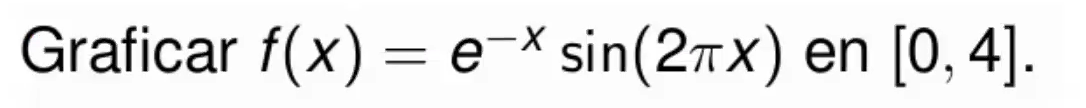



In [ ]:
x = np.arange(0,4,0.5) #args=pto inicial, punto final, espaciamiento
xx = np.linspace(0,4,1000) #args=pto inicial, punto final, cantidad de puntos

y = np.exp(-xx)*np.sin(2*np.pi*xx)
# print(y, type(y), len(y))
plt.plot(xx,y)

plt.ylim(-0.2,0.2)


## ejercicio 4

Crea un programa que gestione las calificaciones de un curso usando funciones. El sistema debe:

a. Registrar notas de estudiantes en diferentes

b. Calcular promedios de cada estudiante

c. Determinar aprobados y reprobados

d. Generar reportes estadisticos

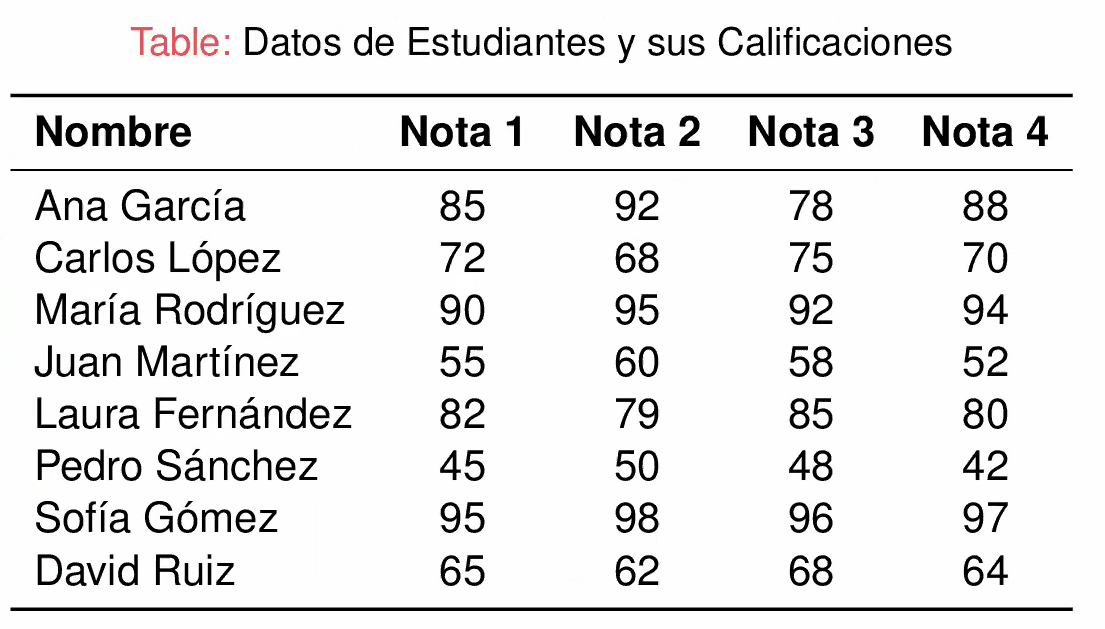

In [ ]:
def registrar_notas():
    datos = [
        {"nombre": "Ana García",      "notas": [85, 92, 78, 88]},
        {"nombre": "Carlos López",    "notas": [72, 68, 75, 70]},
        {"nombre": "María Rodríguez", "notas": [90, 95, 92, 94]},
        {"nombre": "Juan Martínez",   "notas": [55, 60, 58, 52]},
        {"nombre": "Laura Fernández", "notas": [82, 79, 85, 80]},
        {"nombre": "Pedro Sánchez",   "notas": [45, 50, 48, 42]},
        {"nombre": "Sofía Gómez",     "notas": [95, 98, 96, 97]},
        {"nombre": "David Ruiz",      "notas": [65, 62, 68, 64]}
    ]
    return datos

def calcular_promedios(estudiantes):
    for est in estudiantes:
        suma = sum(est["notas"])
        cantidad = len(est["notas"])
        promedio = suma / cantidad
        est["promedio"] = round(promedio, 2) # Redondeamos a 2 decimales
    return estudiantes

def determinar_estado(estudiantes, nota_minima=60):
    for est in estudiantes:
        if est["promedio"] >= nota_minima:
            est["estado"] = "Aprobado"
        else:
            est["estado"] = "Reprobado"
    return estudiantes

def generar_reportes(estudiantes):
    print(f"{'NOMBRE':<20} | {'PROMEDIO':<10} | {'ESTADO':<10}")
    print("-" * 46)

    suma_total = 0
    aprobados = 0
    reprobados = 0

    for est in estudiantes:
        print(f"{est['nombre']:<20} | {est['promedio']:<10} | {est['estado']:<10}")
        suma_total += est["promedio"]

        if est["estado"] == "Aprobado":
            aprobados += 1
        else:
            reprobados += 1

    promedio_curso = suma_total / len(estudiantes)

    print("-" * 46)
    print("\n--- RESUMEN ESTADÍSTICO ---")
    print(f"Promedio general del curso: {promedio_curso:.2f}")
    print(f"Total de Aprobados: {aprobados}")
    print(f"Total de Reprobados: {reprobados}")

    # Extra: Mejor estudiante
    mejor_estudiante = max(estudiantes, key=lambda x: x["promedio"])
    print(f"Mejor promedio: {mejor_estudiante['nombre']} ({mejor_estudiante['promedio']})")

# --- EJECUCIÓN DEL PROGRAMA ---
def main():
    # 1. Registrar (Cargar datos)
    lista_clase = registrar_notas()

    # 2. Calcular Promedios
    lista_clase = calcular_promedios(lista_clase)

    # 3. Determinar Aprobados/Reprobados (Asumiendo nota mínima de 60)
    lista_clase = determinar_estado(lista_clase, nota_minima=60)

    # 4. Generar Reportes
    generar_reportes(lista_clase)

if __name__ == "__main__":
    main()

# CLASE 2


Cifras significativas y redondeo

# CLASE 3


## serie de taylor



In [ ]:
f = lambda x: np.arctan(x) # usando numpy arctan tan inversa

p = lambda x: x

values = [1, 5]

def evaluacion(values, f, p):
  lista = []
  for i in values:
    lista.append([i,f(i), p(i), abs(f(i) - p(i)), abs((f(i)-p(i))/f(i))])

  lista = pd.DataFrame(lista, columns=["values_x", "f(x)", "p(x)", "|f(x)-p(x)| ", "E_r"])

  return lista

evaluacion(values, f, p)




In [ ]:
delta = 2
x0 = 0
ux = np.linspace(x0-delta, x0+delta, 100)
plt.plot(ux, f(ux),  'b', label='$F(x) = \tan^{-1}x$')
plt.plot(ux, p(ux),  'r', label='$P(x) =  x$')
plt.legend()
plt.grid()
plt.xlabel('Eje X')
plt.xlabel('Eje y')

# Ejemplo:
Construir el polinomio de grado 5 para la función $f(x)=tan^{-1}x$, entorno a $x_0=0$

El polinomio de grado 1 es : $$P(x)=f(x_0)+f'(x_0)(x-x_0)+\frac{f''(x_0)}{2!}(x-x_0)^2+\frac{f'''(x_0)}{3!}(x-x_0)^3+\frac{f^{(4)}(x_0)}{4!}(x-x_0)^4+\frac{f^{(5)}(x_0)}{5!}(x-x_0)^5$$

In [ ]:
x = sp.symbols('x')

F = sp.atan(x)
y_prime = sp.diff(F, x)
y_double_prime = sp.diff(F, x, 2)

df_val = sp.lambdify(x, y_double_prime)

print(df_val(0))

y_prime
y_double_prime


Evaluaciones:
\begin{eqnarray}
f(0)&=&0\\
f'(0)&=&1\\
f''(0)&=&0\\
f^{(3)}(0)&=&-2\\
f^{(4)}(0)&=&0\\
f^{(5)}(0)&=&24\\
\end{eqnarray}

$$P(x)=(x-x_0)+\frac{-2}{3!}(x-x_0)^3+\frac{24}{5!}(x-x_0)^5$$

In [ ]:
f = lambda x: np.arctan(x) # usando numpy arctan tan inversa

p = lambda x: x-2/factorial(3)*x**3+24/factorial(5)*x**5

values = [1, 3.5, 5]

evaluacion(values, f, p)

delta = 2
x0 = 0
ux = np.linspace(x0-delta, x0+delta, 100)
plt.plot(ux, f(ux),  'b', label='$F(x) = \tan^{-1}x$')
plt.plot(ux, p(ux),  'r', label='$P(x) =  x$')
plt.legend()
plt.grid()
plt.xlabel('Eje X')
plt.xlabel('Eje y')


## Programacion de taylor de orden n

In [ ]:
x=sp.symbols('x')

def Taylor (f, x0, n):
  polinomio = 0

  for k in range(n+1):
    df = sp.diff(f, x, k)
    df_val = sp.lambdify(x, df)
    polinomio += (df_val(x0)/factorial(k))*(x-x0)**k
  return polinomio

Taylor(sp.atan(x), 0, 5)


# CLASE 4

In [ ]:
g = sp.exp(2*x)*sp.sin(x)
P = Taylor(g, np.pi, 3)
x_values = [1, 4.5]
evaluacion(x_values, sp.lambdify(x, g), sp.lambdify(x, P))


#CLASE 5



## Ceros de Funciones

## Metodoso cerrados

### Metodo de biseccion
 es un metodo que siempre converge y es de una velocidad lenta

se debe garantizar :
teorema de valor intermedio:

sea $f$ una funcion continua en un intervalo $[a, b]$, entonces para cada $k$ tal que $f(a)<k<f(b)$, existe al menos un $c$ que pertence a $[a,b]$ tal que $f(c) = k$

teorema de bolzano (es un derivado del teorema de valor intermedio):

Sea una funcion $f(x)$ continua definida en un intervalo $[a, b]$, entonces si se cumple que $f(a)f(b)<0$ (con signos opuestos), existe un punto $c$ que pertence a $(a, b)$ tal que $f(c)=0$

(solo me garantiza existencia pero no me dice cual es)




### ej 1

sea $f(x) = x^2 -8$, encontrar una proximacion de $\beta$ tal que $f(\beta) = 0$, en el intervalo de [2, 4], con una excatitud de $10^-2$

### ej 1

sea $f(x) = 3^-x -x$, encontrar una proximacion de $\beta$ tal que $f(\beta) = 0$, en el intervalo de [0, 1], con una excatitud de $10^-2$


In [ ]:
f = lambda x: x**2-8

Biseccion(f, 2, 3, 1e-8)

In [ ]:
f = lambda x: 3**(-x)-x

Biseccion(f, 0, 1, 1e-8)

# CLASE 6


## Ceros de Funciones


Suponga el lector que está diseñando un tanque esférico de almacenamiento de agua para un poblado pequeño de un país en desarrollo. El volumen del líquido que puede contener se calcula con $$V=\pi h^2\frac{3R-h}{3}$$
donde V = volumen $[pie^3]$, h = profundidad del agua en el tanque [pies], y R = radio del tanque [pies]. Si $R = 3 ft$, ¿a qué profundidad debe llenarse el tanque de modo que contenga $30 ft^3$
? Haga tres iteraciones del método de Bisección para determinar la respuesta. Encuentre el error absoluto aproximado después de cada iteración.


un porblema de aplicacion se le debe asociar una funcion de ceros, en este caso:
$$f(h)=\pi h^2\frac{3R-h}{3}-V=0$$



In [ ]:
R = 3
V = 30

f_profu = lambda h: np.pi*h**2*((3*R-h)/3)-V
Biseccion(f_profu, 0, 6, 1e-6)


La profundida a la cual debe llenar un tanque esferico de radio $R=3$ y que este contenga un volumen de $V=30ft^3$ es de 2.02690

Una partícula parte del reposo sobre un plano inclinado uniforme, cuyo ángulo $\theta$ cambia con una tasa constante de
$$\frac{d\theta}{dt}=\omega <0$$
Al final de $t$ segundos, la posición del objeto está dada por
$$x(t)=-\frac{g}{2\omega^{2}}\left(\frac{e^{\omega t}-e^{-\omega t}}{2}-\sin(\omega t)\right)$$
suponga que la partícula se desplazo 1.7 pies en 1 segundo. Encuentre con una exactitud de $10^{-5}$, la tasa $\omega$ a la que $\theta$ cambia. Suponga que $g=32,17pies/s^{2}$}

1.Usando el método de la bisección. Determine el numero de iteraciones necesarias si la exactitud es de $10^{-5}$. Y calcule la aproximación.


funcion asociada:
$$-\frac{g}{2\omega^{2}}\left(\frac{e^{\omega t}-e^{-\omega t}}{2}-\sin(\omega t)\right) - x(t)=0$$

In [ ]:
#Se realiza el grafico de la funcion de ceros para estimar un intervalo inical de busqueda
g = 32.17
x = 1.7

w = np.linspace(-5, -1e-3, 100)
omega = lambda w:-g/(2*w**2) * ((np.exp(w) - np.exp(-w))/2 - np.sin(w))-x
Biseccion(omega, -5, -1e-3, 1e-5)

plt.plot(w, omega(w))
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('w')
plt.ylabel('f(w)')
plt.title('Plano inclinado')
plt.grid()
plt.show()

In [ ]:
f_pro = lambda x: x**10-1

print("Posicion Falsa")
PosicionFalsa(f_pro, 0, 3, 1e-6)
print("")
print("Biseccion")
Biseccion(f_pro, 0, 3, 1e-6)

### Ejemplo

Calcular el primer cero positivo diferente del numero cero de la funcion $$f(x) =sin(x)$$


In [ ]:
x = np.linspace(0, 2*np.pi, 100)
f = lambda x: np.sin(x)
print("Biseccion")
Biseccion(f, 3, 3.5, 1e-6)
print("")
print("Posicion Falsa")
PosicionFalsa(f, 3, 3.5, 1e-6)

plt.plot(x, np.sin(x))
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('x')
plt.grid()
plt.show()

errores aproximaciones y taylor
proximo miercoles


#CLASE 7


En ciertas ocasiones, los ingenieros aerospaciales deben calcular las trayectorias de proyectiles, como cohetes. Un problema parecido tiene que ver con la trayectoria de una pelota que
 se lanza. Dicha trayectoria está definida por las coordenadas $(x,y)$, como se ilustra en la figura. Calcule el ángulo inicial  $\theta_{0}$, apropiado si la velocidad inicial $v_{0}= 20 m/s$ y la distancia $x$ al catcher es de $35 m$. Obsérvese que
 la pelota sale de la mano del lanzador con una elevación $y_{0} = 2 m$, y el catcher la recibe a 1 m. Exprese el resultado final en grados.

La trayectoria se modela con la ecuación
\begin{equation*}
y=\tan(\theta_{0})x-\frac{g}{2v_{0}^{2}\cos^{2}\theta_{0}}x^{2}+y_{0}
\end{equation*}

In [ ]:
x = 35
y0 = 3
y = 1
g = 9.8
v0 = 20

f = lambda theta: (x*(np.tan(theta))) - (g*x**2)/(2*v0**2*np.cos(theta)**2) + y0 - y

print('Biseccion')
p = Biseccion(f, 0, np.pi/4, 1e-6)
print(f'El angulo inicial con el cual el lanzador tira la pelota es:{np.degrees(p)}')
print('')

print('Posicion Falsa')
c = PosicionFalsa(f, 0, np.pi/4, 1e-6)
print(f'El angulo inicial de la pelota es:{np.degrees(c)}')

encontrar la raiz de $f(x) = x^2-8

In [ ]:
x = sp.symbols('x')
x0 = 1
tol = 10**(-6)

f = x**2-8


Newton(f, x0, tol)

 La aceleración de una caída en bungee jumping puede modelarse  como:
\begin{equation*}
 a=g+\frac{\frac{1}{2}\mu v^2}{\mu(L-y)+2L}
\end{equation*}

donde $\mu = 5,44$ es la relación de masas de la cadena y el cuerpo lanzado, la longitud de la cadena
es $L = 4,15m$ y la aceleración debida a la gravedad para Medellín es $g = 9,78m/s^2$ . Si la velocidad
alcanzada en el punto de sensación de ingravidez ($ a = 0m/s^2$ ) fue  de $v = 17m/s$ ¿cuál debía ser la
distancia recorrida en caída $y$ medida en metros? Aproxime usando $y = 1m$ con un método abierto.


In [ ]:
g = 9.78
mu = 5.14
L =  4.15
v = 17


f = g + (0.5*mu*v**2)/(mu*(L-x)+2*L)

a, b = Newton(f, 8, 1e-6 )
print(a, b)

# Clase 8 (examen)

# Clase  9


# Funcion ceros es:
$x+y = 20$ ----- La suma de dos numeros es igual a 20, $$(x+\sqrt{x})(y+\sqrt{y})$$

Siempre hay que tener la funcion objetivo... f(variable) = 0

$$(x+\sqrt{x}) (20+\sqrt{20}) - 155.55 = 0$$



In [ ]:
f = lambda x: (x + np.sqrt(x)) * (20 - x + np.sqrt(20 -  x)) - 155.55

print("Biseccion")
Biseccion(f, 5, 7.5, 1e-4)

print("")
print("Posicion Falsa")
PosicionFalsa(f, 12.5, 15, 1e-10000)
print("")



ux =  np.linspace(-20, 20, 100)
plt.plot(ux, f(ux), 'b')
plt.axhline(y=0, color='red', linestyle='--')
plt.grid()

In [ ]:
x = sp.symbols('x')

f = (x + np.sqrt(x)) * (20 - x + np.sqrt(20 -  x)) - 155.55


x_number = Newton(f, 6, 1e-4)
y_number = Newton(f, 7, 1e-4)

print(f'El numero es {x_number + y_number}')

In [ ]:
f = lambda x: x**2-8

Secante(f, 2, 3, 1e-4)



In [ ]:
x = sp.symbols('x')

f = x**2-8

Newton(f, 2, 1e-4)


# Clase 10

### Introduccion Eliminacion Gaussiana

El algoritmos de eleiminacion gaussiana realiza lo que se llama una reduccion de filas en una matriz


$$-3x +2y +z = 2$$

$$6x -8y -2z = 1$$

$$x-y -2z = 3$$




In [ ]:
A = np.array([
    [3,  2,  1],
    [ 6, -8, -2],
    [ 1, -1, -2]
])
b = np.array([2, 1, 3])

def eliminacion_DD(A,b):
  matriz_a = np.hstack((A, b.reshape(-1, 1))).astype(float)
  n=len(b)
  x_solucion = np.zeros_like(b)


  for j in range(n):
    for i in range(j+1, n):
      factor = matriz_a[i,j]/matriz_a[j,j]
      matriz_a[i, 0:n+1] = matriz_a[i, 0:n+1] - factor * matriz_a[j, 0:n+1]
  print(matriz_a)

  for k in range(n-1, -1, -1):
    x_solucion[k]= (matriz_a[k, n] - np.dot(matriz_a[k, k+1:n], x_solucion[k+1:n]))/matriz_a[k, k]

eliminacion_DD(A, b)

In [ ]:
import numpy as np


In [ ]:
B = np.array([[-1, 2, 0], [2, -3, 1], [0, 1, 2]])
eigvalues, eigvector = np.linalg.eig(B)
radio_espectral = max(abs(eigvalues))
print(f'Los valores propios de la matriz son {}')